# Deep Learning Fundamentals: Deep Neural Networks with PyTorch (OpenML Splice)

In the previous session, you built a **simple neural network** in PyTorch on a toy dataset.

In this notebook, you’ll apply deep learning to a **more complex real dataset** from OpenML: **`splice`**.

You will:
- Train a **shallow MLP** baseline
- Train a **deeper neural network**
- Inspect **gradient norms** (a practical signal for vanishing/exploding gradients)
- Apply **regularization** strategies: **Dropout** and **Batch Normalization**

## Learning objectives

By the end of this notebook, you will be able to:
- Build mini-batch training pipelines with `DataLoader`
- Train shallow vs deep multi-layer perceptrons (MLPs)
- Understand when/why to use Dropout and BatchNorm


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print("Imports ready.")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

Imports ready.
PyTorch version: 2.10.0
Using device: mps


## 1. Load and explore the dataset

The [OpenML Splice dataset](https://www.openml.org/search?type=data&sort=runs&id=46&status=active) contains short DNA sequences centered around potential splice junctions. During protein synthesis, DNA is transcribed into RNA, which is then translated into proteins. During the transcription process, there is a difference between the coding and non-coding parts of the DNA sequence (exons and introns respectively). Introns are ignored, while the exons are translated into proteins. Differentiation between these regions is therefore crucial for understanding gene structure and function.

Each sample in the splice dataset includes a 60-base sequence and a class label indicating whether it represents an exon–intron boundary (EI), an intron–exon boundary (IE), or a non–splice site. The classification goal is to automatically recognize these junctions from raw genetic sequences, which is a key step in gene annotation and understanding how organisms translate DNA into functional proteins.

Because the dataset contains categorical features, we will one-hot encode them before we train the neural network classifier.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- How many samples do we have?
- How many classes are there, and are they balanced?
- What do the raw features look like before one-hot encoding?
</div>

In [2]:
# Fetch dataset from OpenML (requires internet the first time; afterwards it may be cached)
ds = fetch_openml(data_id=46, as_frame=True)  # 46 = splice
df_full = ds.frame.copy()

X_df = df_full.drop(columns="Class")
y_raw = df_full["Class"].astype(str)

## INSERT YOUR CODE HERE TO COMPUTE THE NUMBER OF FEATURES/SAMPLES/CLASS DISTRIBUTION

df_full.head()

,attribute_1,attribute_2,attribute_3,attribute_4,attribute_5,attribute_6,attribute_7,attribute_8,attribute_9,attribute_10,...,attribute_52,attribute_53,attribute_54,attribute_55,attribute_56,attribute_57,attribute_58,attribute_59,attribute_60,Class
0,C,C,A,G,C,T,G,C,A,T,...,G,C,C,A,G,T,C,T,G,EI
1,A,G,A,C,C,C,G,C,C,G,...,T,G,C,C,C,C,C,G,C,EI
2,G,A,G,G,T,G,A,A,G,G,...,A,C,G,G,G,G,A,T,G,EI
3,G,G,G,C,T,G,C,G,T,T,...,G,T,T,T,T,C,C,C,C,EI
4,G,C,T,C,A,G,C,C,C,C,...,C,T,T,G,A,C,C,C,T,EI


### Train/validation/test split + preprocessing

Because the features are categorical (DNA base per position), we will use:
- **One-hot encoding** for the input features (converts categories to binary vectors)
- **Label encoding** for the target labels (strings → integers)

We then build PyTorch **DataLoaders** for **mini-batch training**:
- Instead of updating the model for each sample separately, we compute the average gradient over small batches (e.g., 128 samples)
- This leads to more stable learning and often better generalization
- It's the standard approach in deep learning

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why do we use a validation set during training (instead of the test set)?
- How many features do we have before and after one-hot encoding? Is this what you expected?
- What's the advantage of mini-batch training over using the full dataset at once?
</div>

In [18]:
# Split: train vs (val+test)
X_train_df, X_temp_df, y_train_raw, y_temp_raw = train_test_split(
    X_df, y_raw, test_size=0.30, random_state=42, stratify=y_raw
)

# Split: val vs test (15% / 15%)
X_val_df, X_test_df, y_val_raw, y_test_raw = train_test_split(
    X_temp_df, y_temp_raw, test_size=0.50, random_state=42, stratify=y_temp_raw
)

print(f"Train: {X_train_df.shape} | Val: {X_val_df.shape} | Test: {X_test_df.shape}")

# One-hot encoding
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_np = ohe.fit_transform(X_train_df)
X_val_np = ohe.transform(X_val_df)
X_test_np = ohe.transform(X_test_df)

# --- Encode y (string -> int) ---
label_enc = LabelEncoder()
y_train_np = label_enc.fit_transform(y_train_raw)
y_val_np = label_enc.transform(y_val_raw)
y_test_np = label_enc.transform(y_test_raw)

class_names = list(label_enc.classes_)
num_classes = len(class_names)
input_dim = X_train_np.shape[1]

print(f"After one-hot: input_dim={input_dim}")
print(f"Classes: {class_names}")

# Convert to tensors
X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
X_val_t = torch.tensor(X_val_np, dtype=torch.float32)
X_test_t = torch.tensor(X_test_np, dtype=torch.float32)

y_train_t = torch.tensor(y_train_np, dtype=torch.long)
y_val_t = torch.tensor(y_val_np, dtype=torch.long)
y_test_t = torch.tensor(y_test_np, dtype=torch.long)

# DataLoaders
batch_size = 128
g = torch.Generator().manual_seed(42)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train: (2233, 60) | Val: (478, 60) | Test: (479, 60)
After one-hot: input_dim=285
Classes: ['EI', 'IE', 'N']
Batch size: 128
Train batches: 18 | Val batches: 4 | Test batches: 4


## 2. Train and evaluate a base (shallow) neural network

A **Multilayer Perceptron (MLP)** is a feedforward neural network made of fully-connected layers.

Baseline architecture:
- Input: `input_dim` (one-hot encoded features)
- Hidden layer: 64 neurons + ReLU
- Output: `num_classes` classes

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why do we use ReLU between layers?
- How many neurons do we need in the output layer?
- Why do we NOT put a softmax layer at the end when using `CrossEntropyLoss`?
</div>

In [19]:
class ShallowMLP(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

shallow_model = ShallowMLP(input_size=input_dim, hidden_size=64, num_classes=num_classes).to(device)
print(shallow_model)
print(f"\nTotal parameters: {sum(p.numel() for p in shallow_model.parameters())}")

ShallowMLP(
  (fc1): Linear(in_features=285, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)

Total parameters: 18499


### Loss function, optimizer, and training utilities

We will use:
- **Cross-entropy loss** for multiclass classification
- **Adam** optimizer (adaptive learning rate for each parameter)

We also define helper functions to:
- **Evaluate accuracy** from raw model outputs (logits)
- **Evaluate entire datasets** efficiently using DataLoaders
- **Fit models** with a clean training loop

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- What does the learning rate control?
- Why do we call `model.train()` during training and `model.eval()` during evaluation?
</div>

In [20]:
def accuracy_from_logits(logits, y_true):
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

@torch.no_grad()
def evaluate_loader(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    # Evaluation loop (mini-batches)
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch) # Batch predictions
        loss = criterion(outputs, y_batch) # Batch prediction loss

        bs = y_batch.shape[0]
        total_loss += loss.item() * bs # Add to the total loss (weighted by the number of samples in the batch)
        total_correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, num_epochs, device):
    training_loss = []
    validation_loss = []
    training_accuracy = []
    validation_accuracy = []

    for epoch in range(num_epochs):
        # Training loop (mini-batches)
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch) # Batch predictions
            loss = criterion(outputs, y_batch) # Batch prediction loss

            optimizer.zero_grad() # Set gradients to zero
            loss.backward() # Compute gradients (backpropagation)
            optimizer.step() # Optimization step

        # Evaluate on full train/val sets (still via DataLoader)
        train_loss, train_acc = evaluate_loader(model, train_loader, criterion, device)
        val_loss, val_acc = evaluate_loader(model, val_loader, criterion, device)

        training_loss.append(train_loss)
        validation_loss.append(val_loss)
        training_accuracy.append(train_acc)
        validation_accuracy.append(val_acc)

        if epoch == 0 or (epoch + 1) % 10 == 0 or (epoch + 1) == num_epochs:
            print(
                f"Epoch {epoch+1:3d}/{num_epochs} | "
                f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
                f"train_acc={train_acc*100:.2f}% val_acc={val_acc*100:.2f}%"
            )

    return {
        "train_loss": training_loss,
        "val_loss": validation_loss,
        "train_acc": training_accuracy,
        "val_acc": validation_accuracy,
    }

In [21]:
# Training parameters
num_epochs = 40
learning_rate = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(shallow_model.parameters(), lr=learning_rate)

shallow_history = fit(
    shallow_model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    num_epochs=num_epochs,
    device=device,
 )

train_loss, train_acc = evaluate_loader(shallow_model, train_loader, criterion, device)
val_loss, val_acc = evaluate_loader(shallow_model, val_loader, criterion, device)
test_loss, test_acc = evaluate_loader(shallow_model, test_loader, criterion, device)

print(f"Shallow MLP | Train acc: {train_acc*100:.2f}% | Val acc: {val_acc*100:.2f}% | Test acc: {test_acc*100:.2f}%")

Epoch   1/40 | train_loss=0.8658 val_loss=0.8762 | train_acc=51.86% val_acc=51.88%
Epoch  10/40 | train_loss=0.0955 val_loss=0.1676 | train_acc=97.76% val_acc=94.35%
Epoch  20/40 | train_loss=0.0534 val_loss=0.1761 | train_acc=98.97% val_acc=94.56%
Epoch  30/40 | train_loss=0.0331 val_loss=0.1946 | train_acc=99.42% val_acc=94.35%
Epoch  40/40 | train_loss=0.0218 val_loss=0.2212 | train_acc=99.73% val_acc=93.51%
Shallow MLP | Train acc: 99.73% | Val acc: 93.51% | Test acc: 94.57%


### Visualize Training Progress

We plot both loss and accuracy curves. The **solid lines** show training metrics, while **dashed lines** show validation metrics.

**What to look for:**
- **Good fit**: Train and validation curves close together and still improving
- **Underfitting**: Both curves plateau at poor performance
- **Overfitting**: Training continues improving while validation gets worse

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- How do the training and validation curves compare?
- What does that pattern suggest?
- Around which epoch did the model stop improving on validation data?
</div>

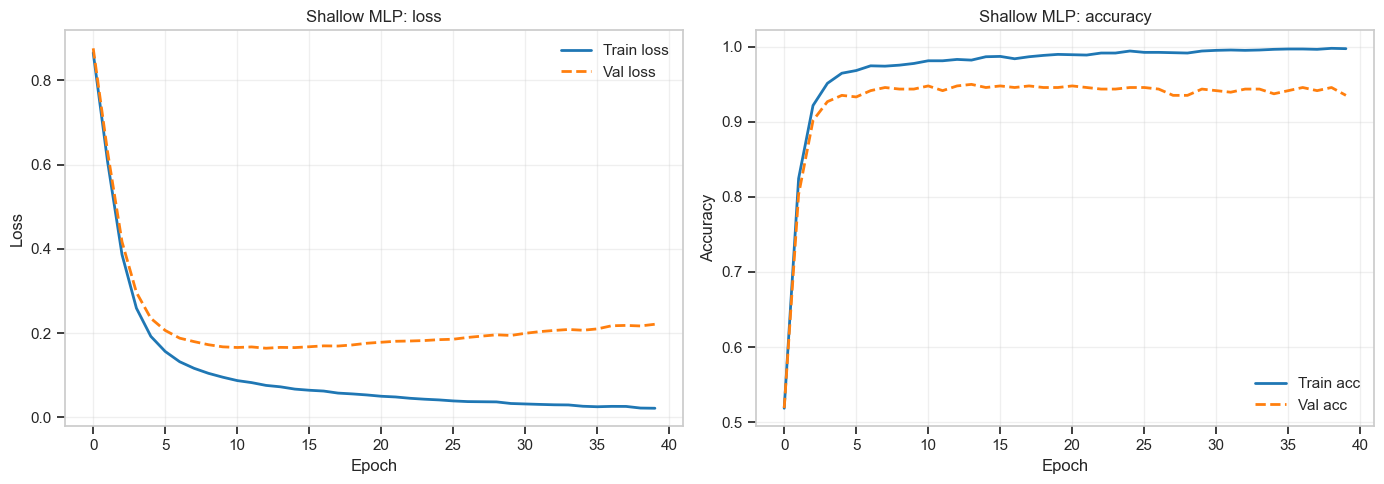

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Solid=train, dashed=val
ax1.plot(shallow_history["train_loss"], label="Train loss", linewidth=2, linestyle="-")
ax1.plot(shallow_history["val_loss"], label="Val loss", linewidth=2, linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Shallow MLP: loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(shallow_history["train_acc"], label="Train acc", linewidth=2, linestyle="-")
ax2.plot(shallow_history["val_acc"], label="Val acc", linewidth=2, linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Shallow MLP: accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluate on the Test Set

We now evaluate the trained model on the **held-out test set** that it has never seen before. This gives us an unbiased estimate of real-world performance.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Which classes are most often confused?
- Are mistakes symmetric (Class A→B as often as B→A)? Why or why not?
- How does test accuracy compare to validation accuracy?
</div>

Test accuracy: 94.57%


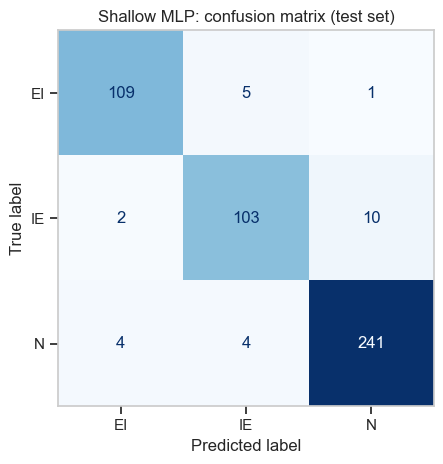

In [23]:
@torch.no_grad()
def predict_from_loader(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_preds = []
    all_true = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.append(preds)
        all_true.append(y_batch.numpy())

    return np.concatenate(all_preds), np.concatenate(all_true)

y_pred, y_true = predict_from_loader(shallow_model, test_loader, device)
print(f"Test accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d", colorbar=False)
plt.grid(False)
plt.title("Shallow MLP: confusion matrix (test set)")
plt.tight_layout()
plt.show()

## 3. Build and Train a Deep Neural Network

A **deep** neural network stacks many hidden layers. This can:
- **Increase representational power** (learn more complex patterns)
- **Automatically learn hierarchical features**
- **Risk overfitting** (especially with limited data)
- **Be harder to optimize** (vanishing/exploding gradients)

We'll create a much deeper network (10 hidden layers!) and see what happens.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why might a deeper network overfit more easily?
- If the deep model performs worse, what could be the reasons?
- How many more parameters does this deep model have compared to the shallow one?
</div>

In [ ]:
class DeepMLP(nn.Module):
    def __init__(self, input_size: int, hidden_sizes: list[int], num_classes: int):
        super().__init__()

        layers = []
        prev = input_size
        for hs in hidden_sizes:
            layers.append(nn.Linear(prev, hs))
            layers.append(nn.ReLU())
            prev = hs
        layers.append(nn.Linear(prev, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

deep_model = DeepMLP(input_size=input_dim, hidden_sizes=[256, 128, 128, 128, 128, 128, 128, 128, 128, 64], num_classes=num_classes).to(device)
print(deep_model)
print(f"\nTotal parameters: {sum(p.numel() for p in deep_model.parameters())}")

DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=285, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): ReLU()
    (14): Linear(in_features=128, out_features=128, bias=True)
    (15): ReLU()
    (16): Linear(in_features=128, out_features=128, bias=True)
    (17): ReLU()
    (18): Linear(in_features=128, out_features=64, bias=True)
    (19): ReLU()
    (20): Linear(in_features=64, out_features=64, bias=True)
    (21): ReLU()
    (22): Linear(in_features=64, out_features=64, bias=True)
    (23): ReLU()
    (24): Linear(in_featu

### Train the Deep Model

Notice we're training for **more epochs** (60 vs 40) because deep networks often need more time to converge.

**Note**: This will take longer to train due to the increased depth!

In [41]:
# Training parameters
num_epochs = 60
learning_rate = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(deep_model.parameters(), lr=learning_rate)

deep_history = fit(
    deep_model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    num_epochs=num_epochs,
    device=device,
 )

train_loss, train_acc = evaluate_loader(deep_model, train_loader, criterion, device)
val_loss, val_acc = evaluate_loader(deep_model, val_loader, criterion, device)
test_loss, test_acc = evaluate_loader(deep_model, test_loader, criterion, device)

print(f"Deep MLP | Train acc: {train_acc*100:.2f}% | Val acc: {val_acc*100:.2f}% | Test acc: {test_acc*100:.2f}%")

Epoch   1/60 | train_loss=1.1199 val_loss=1.1199 | train_acc=24.09% val_acc=24.06%
Epoch  10/60 | train_loss=0.5234 val_loss=0.5885 | train_acc=73.76% val_acc=72.18%
Epoch  20/60 | train_loss=0.1198 val_loss=0.7021 | train_acc=99.55% val_acc=92.68%
Epoch  30/60 | train_loss=0.0306 val_loss=1.3147 | train_acc=99.60% val_acc=93.31%
Epoch  40/60 | train_loss=0.0228 val_loss=1.6881 | train_acc=99.64% val_acc=93.93%
Epoch  50/60 | train_loss=0.0180 val_loss=3.1523 | train_acc=99.69% val_acc=94.14%
Epoch  60/60 | train_loss=0.0158 val_loss=3.0124 | train_acc=99.69% val_acc=94.14%
Deep MLP | Train acc: 99.69% | Val acc: 94.14% | Test acc: 93.11%


### Compare Shallow vs Deep Performance

Let's visualize how the deep network learned compared to the shallow baseline.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- How does the deep network compare to the shallow baseline?
- What do you see in the training curves?
- What does this tell you about the training of the deep network?
- How could you improve the training of the deep network?
</div>

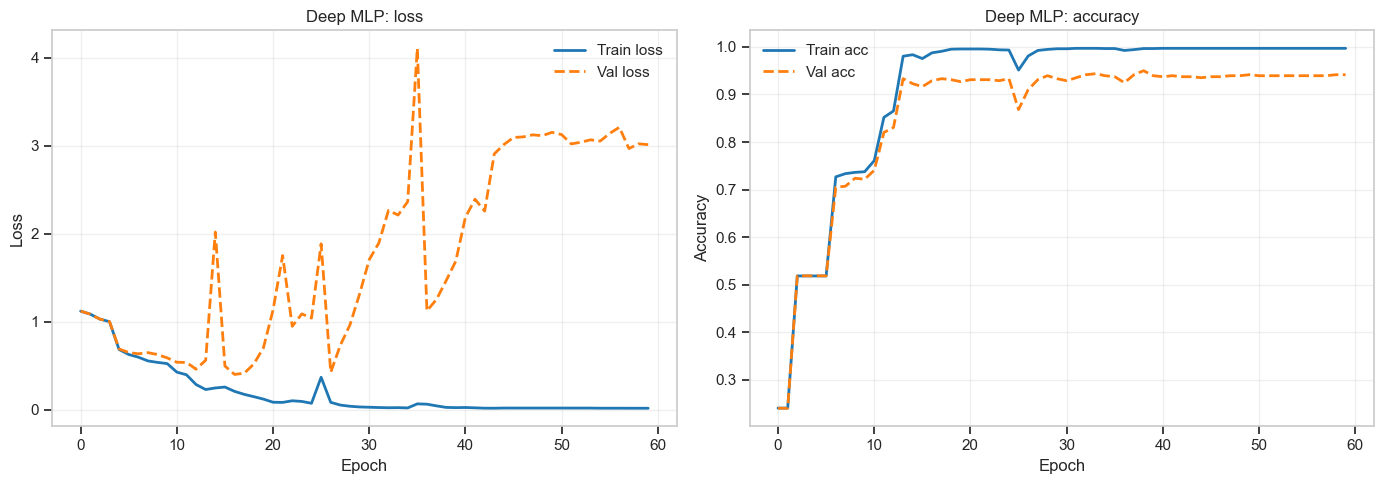

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Solid=train, dashed=val
ax1.plot(deep_history["train_loss"], label="Train loss", linewidth=2, linestyle="-")
ax1.plot(deep_history["val_loss"], label="Val loss", linewidth=2, linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Deep MLP: loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(deep_history["train_acc"], label="Train acc", linewidth=2, linestyle="-")
ax2.plot(deep_history["val_acc"], label="Val acc", linewidth=2, linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Deep MLP: accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Deep Model Test Set Evaluation

Now let's see how the deep model performs on unseen test data and compare it to our shallow baseline.

Test accuracy: 93.11%


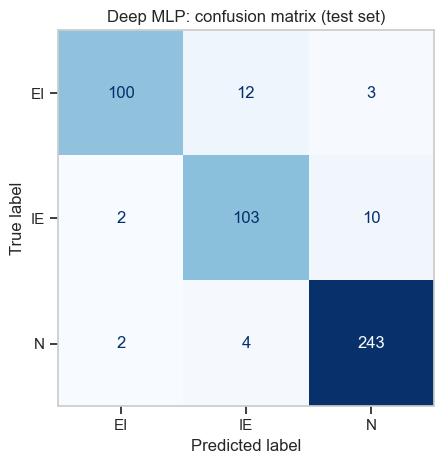

In [43]:
y_pred, y_true = predict_from_loader(deep_model, test_loader, device)
print(f"Test accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d", colorbar=False)
plt.grid(False)
plt.title("Deep MLP: confusion matrix (test set)")
plt.tight_layout()
plt.show()

### Understanding Gradient Flow in Deep Networks

When training deep networks, gradients can **vanish** (become too small) or **explode** (become too large) as they propagate backward through many layers.

Let's inspect the gradient magnitudes after one training step to see if our deep network has gradient flow problems.

**What the numbers mean:**
- **Very small** (~1e-6 or smaller): Gradients are vanishing → early layers learn very slowly
- **Very large** (~1e3 or larger): Gradients are exploding → training becomes unstable
- **Moderate** (~1e-4 to 1e-1): Healthy gradient flow

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Do you see a pattern in gradient magnitudes from early to late layers?
- Are any layers barely learning (very small gradients)?
- Why might regularization techniques help with gradient flow?
</div>

In [44]:
# First, do one training step to populate gradients
deep_model.train()
X_batch, y_batch = next(iter(train_loader))
X_batch, y_batch = X_batch.to(device), y_batch.to(device)

outputs = deep_model(X_batch)
loss = criterion(outputs, y_batch)
loss.backward()

# Now inspect gradient norms for each layer
print("Gradient norms by layer (after one backward pass):")
print("=" * 60)
for name, param in deep_model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm().item()
        # Color code the output based on magnitude
        if grad_norm < 1e-5:
            status = "⚠️ Very small (vanishing?)"
        elif grad_norm > 1e2:
            status = "⚠️ Very large (exploding?)"
        else:
            status = "✓ OK"
        print(f"{name:40s}: {grad_norm:10.4e}  {status}")

Gradient norms by layer (after one backward pass):
net.0.weight                            : 1.8070e-02  ✓ OK
net.0.bias                              : 2.5244e-03  ✓ OK
net.2.weight                            : 5.4542e-03  ✓ OK
net.2.bias                              : 2.8133e-03  ✓ OK
net.4.weight                            : 2.0967e-03  ✓ OK
net.4.bias                              : 4.3993e-03  ✓ OK
net.6.weight                            : 1.2124e-03  ✓ OK
net.6.bias                              : 4.5225e-03  ✓ OK
net.8.weight                            : 1.8024e-03  ✓ OK
net.8.bias                              : 5.4932e-03  ✓ OK
net.10.weight                           : 1.5788e-03  ✓ OK
net.10.bias                             : 5.0422e-03  ✓ OK
net.12.weight                           : 1.1200e-03  ✓ OK
net.12.bias                             : 2.0424e-03  ✓ OK
net.14.weight                           : 9.0145e-04  ✓ OK
net.14.bias                             : 7.3626e-04  ✓ OK
net.1

## 4. Regularization: Making Deep Networks Work Better

Deep networks can overfit and be harder to optimize. Two powerful techniques help:

**Batch Normalization (BatchNorm)**
- Normalizes activations within each mini-batch
- **Helps**: Stabilizes training, allows higher learning rates, reduces internal covariate shift
- **When to use**: Almost always in deep networks (especially CNNs)

**Dropout**
- Randomly "drops out" (sets to zero) a fraction of neurons during training
- **Helps**: Prevents co-adaptation of neurons, acts as ensemble regularization
- **When to use**: When you see overfitting (train acc >> val acc)

We'll train **four versions** of the same architecture:
1. No regularization (baseline)
2. Dropout only
3. BatchNorm only  
4. BatchNorm + Dropout

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why does dropout only apply during training?
- How might batch normalization affect training speed and stability?
- What do you expect: will regularization increase or decrease training accuracy?
- What about validation accuracy?
</div>

In [35]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_sizes: list[int],
        num_classes: int,
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        layers.append(nn.Linear(prev, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def plot_runs_overlay(runs: dict, title: str):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for name, hist in runs.items():
        # Train = solid
        ax1.plot(hist["train_loss"], linewidth=2, label=f"{name} (train)")
        ax2.plot(hist["train_acc"], linewidth=2, label=f"{name} (train)")
        # Val = dashed, hide duplicate legend labels
        ax1.plot(hist["val_loss"], linewidth=2, linestyle="--", label=f"{name} (val)")
        ax2.plot(hist["val_acc"], linewidth=2, linestyle="--", label=f"{name} (val)")

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss")
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Accuracy")
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

### Train All Four Variants

We'll train all four models and collect their learning curves. This will take a few minutes...

Epoch   1/80 | train_loss=0.9990 val_loss=1.0003 | train_acc=51.86% val_acc=51.88%
Epoch  10/80 | train_loss=0.1847 val_loss=0.8305 | train_acc=98.52% val_acc=92.47%
Epoch  20/80 | train_loss=0.0163 val_loss=0.3581 | train_acc=99.64% val_acc=94.14%
Epoch  30/80 | train_loss=0.0065 val_loss=0.3707 | train_acc=99.64% val_acc=94.35%
Epoch  40/80 | train_loss=0.0038 val_loss=0.7331 | train_acc=99.73% val_acc=93.93%
Epoch  50/80 | train_loss=0.0011 val_loss=1.3048 | train_acc=99.96% val_acc=93.51%
Epoch  60/80 | train_loss=0.0010 val_loss=1.3513 | train_acc=99.96% val_acc=93.31%
Epoch  70/80 | train_loss=0.0010 val_loss=1.3618 | train_acc=99.96% val_acc=93.31%
Epoch  80/80 | train_loss=0.0009 val_loss=1.4000 | train_acc=99.96% val_acc=93.31%
Epoch   1/80 | train_loss=0.9981 val_loss=0.9996 | train_acc=51.86% val_acc=51.88%
Epoch  10/80 | train_loss=0.2709 val_loss=0.5328 | train_acc=95.30% val_acc=89.12%
Epoch  20/80 | train_loss=0.0189 val_loss=0.3610 | train_acc=99.64% val_acc=94.98%
Epoc

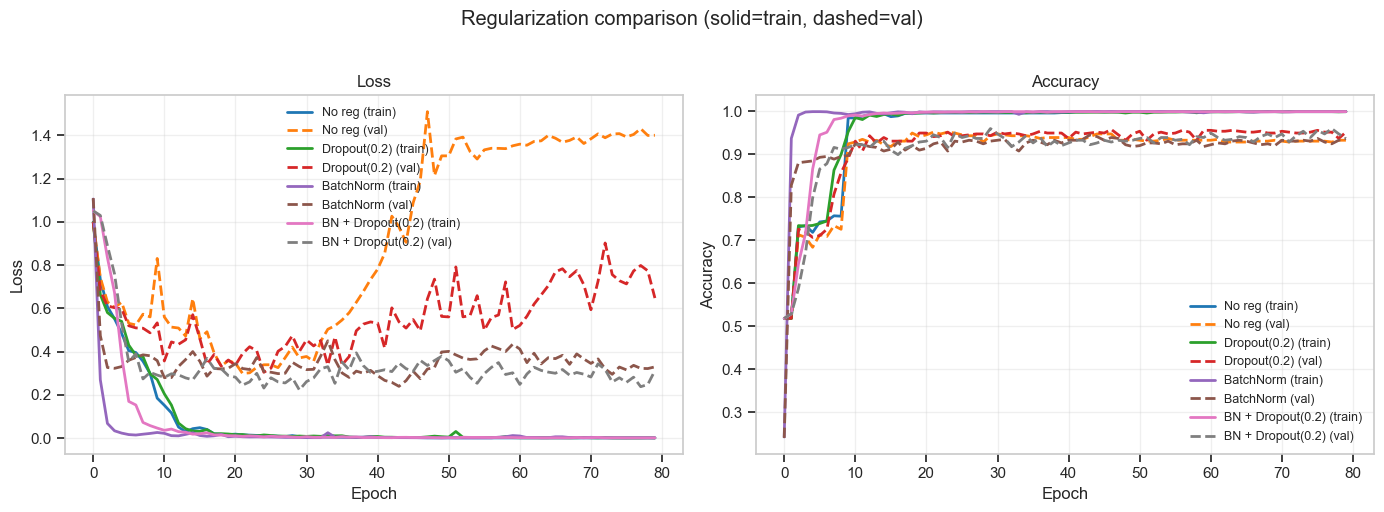

In [36]:
reg_epochs = 80
reg_lr = 1e-3

hidden = [256, 128, 128, 128, 128, 128, 128, 128, 128, 64]

runs = {}

def train_run(name, dropout_p, use_batchnorm):
    model = MLP(input_dim, hidden, num_classes, dropout_p=dropout_p, use_batchnorm=use_batchnorm).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=reg_lr)
    hist = fit(model, train_loader, val_loader, optimizer, criterion, num_epochs=reg_epochs, device=device)
    return model, hist

models = {}

models["No reg"], runs["No reg"] = train_run("No reg", dropout_p=0.0, use_batchnorm=False)
models["Dropout(0.2)"], runs["Dropout(0.2)"] = train_run("Dropout(0.2)", dropout_p=0.2, use_batchnorm=False)
models["BatchNorm"], runs["BatchNorm"] = train_run("BatchNorm", dropout_p=0.0, use_batchnorm=True)
models["BN + Dropout(0.2)"], runs["BN + Dropout(0.2)"] = train_run("BN + Dropout(0.2)", dropout_p=0.2, use_batchnorm=True)

plot_runs_overlay(runs, title="Regularization comparison (solid=train, dashed=val)")

### Test Set Evaluation: The Final Verdict

Based on the previous results, we can select the best model by choosing the one with the best predictive performance on the validation data (highest accuracy or lowest loss). Now let's see how it performs on the test set—data it has truly never seen before.

This is the most honest measure of real-world performance!

Test accuracy (No reg): 91.86%


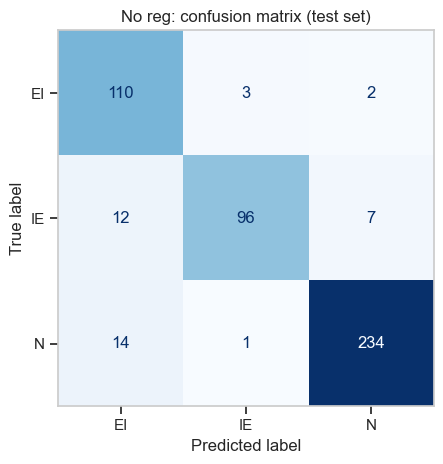

In [37]:
# Evaluate the best regularized model on the test set (based on val_acc)
best_name = "No reg"
best_model = models[best_name]
y_pred, y_true = predict_from_loader(best_model, test_loader, device)
print(f"Test accuracy ({best_name}): {accuracy_score(y_true, y_pred)*100:.2f}%")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d", colorbar=False)
plt.grid(False)
plt.title(f"{best_name}: confusion matrix (test set)")
plt.tight_layout()
plt.show()

## 5. Key Takeaways

Congratulations! You've explored deep learning on a real-world dataset. Here's what we learned:

### Architecture Insights:
- **Deeper ≠ Better**: More layers increase capacity but also overfitting risk
- **Parameters matter**: Deep networks have many more parameters to learn
- **Sweet spot exists**: There's an optimal depth for each dataset/problem

### Training Dynamics:
- **Mini-batch training** is the standard approach (efficient + better generalization)
- **Gradient flow** can be problematic in very deep networks
- **Learning curves** tell the story: watch train vs validation gap!

### Regularization Strategies:
- **Batch Normalization**: Stabilizes training, enables deeper networks
- **Dropout**: Reduces overfitting when you have limited data
- **Combination**: Often works best, but test empirically!

### Best Practices Applied:
✅ Always use train/val/test splits (never evaluate on training data)  
✅ Monitor validation metrics to detect overfitting early  
✅ Compare multiple approaches systematically  
✅ Use regularization when validation performance lags behind training  
✅ Leverage GPU when available for faster experimentation  

### What's Next?
In practice, you would:
1. Try more architectures (different depths/widths)
2. Tune hyperparameters (learning rate, batch size, dropout rate)
3. Use **early stopping** (stop when validation stops improving)
4. Perform cross-validation for more reliable estimates

**Ready to experiment?** Try the optional exercises below!

***
## Optional Exercises (for early finishers)

### A. Batch Size Experiments
Try different batch sizes (32, 128, 512). What changes?
- Training speed (time per epoch)
- Training stability (smoothness of curves)  
- Final validation accuracy
- Memory usage (larger batches use more memory)

**Hypothesis**: Smaller batches → noisier gradients but better generalization?

### B. Architecture Search
Design your own architecture:
- Try different numbers of layers (3, 5, 7)
- Try different layer widths (32, 64, 128, 256)
- Try residual connections (skip connections)

**Challenge**: Can you beat the best regularized model?

### C. Dropout Rate Tuning
Try dropout rates: 0.1, 0.2, 0.3, 0.4, 0.5
- Plot validation accuracy vs dropout rate
- Find the optimal dropout probability
- Does it depend on model depth?

### D. Weight Decay (L2 Regularization)
Add `weight_decay` to the optimizer (e.g., `weight_decay=1e-4`)
- Compare to Dropout and BatchNorm
- Can you combine all three?

### E. Early Stopping
Implement early stopping:
- Save the model when validation loss improves
- Stop training if no improvement for N epochs
- Compare final test accuracy with/without early stopping

<div class="alert alert-block alert-success">
<b>💡 EXPLORATION TIP</b>

When experimenting:
1. Change ONE thing at a time
2. Run multiple random seeds (due to randomness)
3. Keep notes of what works and what doesn't
4. Visualize results to build intuition

Deep learning is as much art as science—learn by doing!
</div>

In [17]:
# -------------------------------
# INSERT YOUR OWN CODE HERE
# -------------------------------

# Example: Experiment with different architectures
class CustomDeepNetwork(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        # Try your own architecture here!
        # Ideas:
        # - Different numbers of layers
        # - Different layer sizes
        # - Different activation functions (LeakyReLU, ELU, etc.)
        # - Residual connections
        pass

    def forward(self, x):
        # Define forward pass here
        pass

# Example training template:
"""
your_model = CustomDeepNetwork(input_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(your_model.parameters(), lr=1e-3, weight_decay=1e-4)

your_history = fit(
    your_model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    num_epochs=60,
    device=device
)

# Evaluate
y_pred, y_true = predict_from_loader(your_model, test_loader, device)
print(f"Your model test accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
"""

# TODO: Train and evaluate your model
# TODO: Compare with the best regularized model from above
# TODO: Visualize learning curves
# TODO: Analyze what worked and what didn't

'\nyour_model = CustomDeepNetwork(input_dim, num_classes).to(device)\ncriterion = nn.CrossEntropyLoss()\noptimizer = optim.Adam(your_model.parameters(), lr=1e-3, weight_decay=1e-4)\n\nyour_history = fit(\n    your_model,\n    train_loader,\n    val_loader,\n    optimizer,\n    criterion,\n    num_epochs=60,\n    device=device\n)\n\n# Evaluate\ny_pred, y_true = predict_from_loader(your_model, test_loader, device)\nprint(f"Your model test accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")\n'